# 02. Enriquecimiento con variables contextuales

Este notebook incorpora a la serie diaria de pedidos las variables
contextuales externas identificadas en el estado del arte como
condicionantes del comportamiento de la demanda en restauración:
las condiciones meteorológicas y los días festivos.

El uso de variables contextuales es lo que diferencia este modelo del modelo de referencia.
Mientras que SARIMA se limita a explotar los patrones internos de la serie
temporal, Prophet permite incorporar estas variables como regresores
externos, lo que debería traducirse en una mejora de la precisión
predictiva.

Las fuentes de datos utilizadas son:

- **Open-Meteo** ([open-meteo.com](https://open-meteo.com)): API de
  código abierto que proporciona datos meteorológicos históricos
  basados en el modelo de reanálisis ERA5 del ECMWF, con resolución
  horaria.
- **Librería `holidays`**: calendarios de festivos nacionales y
  regionales de más de 130 países, integrable de forma nativa con
  Prophet.

Las decisiones metodológicas principales que se toman en este notebook
son las siguientes:

- Definir empíricamente la **ventana de servicio del restaurante** a
  partir del perfil horario de pedidos, para poder construir
  agregaciones meteorológicas funcionalmente relevantes.
- Calcular dos **conjuntos de agregaciones meteorológicas** a nivel
  diario (24 horas completas y ventana de servicio), que se
  compararán como regresores candidatos en la fase de modelado.
- Diseñar la carga de festivos como una **función parametrizable** con
  tres niveles de especificidad (nacional, regional y local), de forma
  que el sistema sea aplicable a cualquier restaurante
  independientemente de su ubicación.

Al finalizar el notebook se obtiene un dataset enriquecido con una fila
por día y columnas para el número de pedidos, las variables
meteorológicas agregadas en los dos conjuntos, una variable binaria de
festivo y el nombre del festivo correspondiente.

## 1. Configuración inicial y carga de la serie base

Se cargan los paquetes necesarios y se recupera la serie diaria de
pedidos generada en el notebook anterior. Esta serie es el punto de
partida al que se incorporarán las variables contextuales.

Se define también la ubicación geográfica del restaurante (Londres)
y la ventana temporal del análisis, que serán parámetros de las
llamadas a las APIs externas.

In [24]:
import pandas as pd
import requests
import holidays
from pathlib import Path

# Rutas del proyecto
DATA_PROCESSED = Path("../data/processed")
DATA_EXTERNAL = Path("../data/external")
DATA_EXTERNAL.mkdir(parents=True, exist_ok=True)

# Parámetros del restaurante (Londres)
LATITUD = 51.5074
LONGITUD = -0.1278
PAIS_CODIGO = "GB"  # Reino Unido, código ISO 3166-1
SUBDIVISION = "ENG" # Inglaterra (subdivisión del Reino Unido, para obtener los festivos regionales)

# Carga de la serie diaria generada en el notebook anterior
serie = pd.read_csv(
    DATA_PROCESSED / "serie_diaria_pedidos.csv",
    parse_dates=["fecha"]
)

print(f"Serie cargada: {len(serie):,} días")
print(f"Rango temporal: {serie['fecha'].min().date()} → {serie['fecha'].max().date()}")
print(f"\nPrimeras 3 filas:")
serie.head(3)

Serie cargada: 1,067 días
Rango temporal: 2016-09-01 → 2019-08-03

Primeras 3 filas:


,fecha,n_pedidos,anio
0,2016-09-01,10,2016.0
1,2016-09-02,20,2016.0
2,2016-09-03,35,2016.0


## 2. Análisis del perfil horario y definición de la ventana de servicio

Antes de agregar las variables meteorológicas a nivel diario, se va a
identificar la ventana horaria en la que se concentra la actividad
del restaurante. Esta ventana es relevante porque el clima que
condiciona la decisión del cliente es el del momento en que se realiza
el pedido, no el promedio de las 24 horas del día.

Si solo se tiene en cuenta el clima durante las horas en las que realmente hay pedidos, la señal es más representativa.
Si un día presenta una mañana desapacible pero una tarde-noche agradable, el promedio
diario lo clasifica como "día regular", cuando desde el punto de vista
operativo del restaurante es "día bueno".

Se calculan en este notebook ambas agregaciones (diaria completa y por
ventana de servicio) para incorporarlas como conjuntos alternativos de
regresores al modelo, y comparar su aportación en la fase de
entrenamiento.

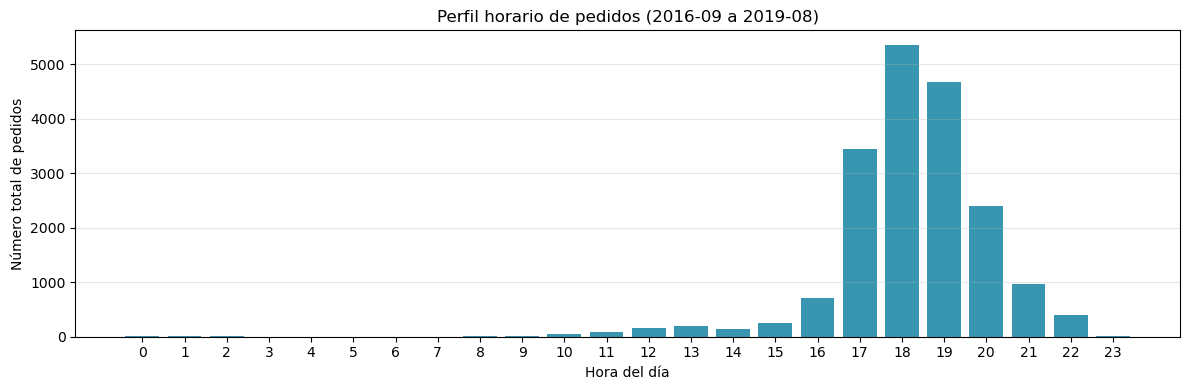


Distribución de pedidos por hora:
 hora  n_pedidos  porcentaje
    0         22        0.12
    1         13        0.07
    2         12        0.06
    3          4        0.02
    6          1        0.01
    8          8        0.04
    9         10        0.05
   10         49        0.26
   11         81        0.43
   12        156        0.83
   13        197        1.04
   14        137        0.72
   15        251        1.33
   16        702        3.71
   17       3452       18.26
   18       5353       28.31
   19       4675       24.73
   20       2395       12.67
   21        973        5.15
   22        404        2.14
   23         11        0.06


In [25]:
# Cargamos los pedidos únicos con hora para analizar el perfil horario
pedidos = pd.read_csv(
    DATA_PROCESSED / "pedidos_unicos.csv",
    parse_dates=["order_datetime"]
)

# Filtramos por la ventana de entrenamiento (a partir de 2016-09-01)
pedidos = pedidos[pedidos["order_datetime"] >= "2016-09-01"].copy()

# Extraemos la hora de cada pedido
pedidos["hora"] = pedidos["order_datetime"].dt.hour

# Calculamos el número medio de pedidos por hora
perfil_horario = (
    pedidos
    .groupby("hora")
    .size()
    .rename("n_pedidos")
    .reset_index()
)
perfil_horario["porcentaje"] = (perfil_horario["n_pedidos"] / perfil_horario["n_pedidos"].sum() * 100).round(2)

# Visualización
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(perfil_horario["hora"], perfil_horario["n_pedidos"], color="#3896b0")
ax.set_title("Perfil horario de pedidos (2016-09 a 2019-08)")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Número total de pedidos")
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\nDistribución de pedidos por hora:")
print(perfil_horario.to_string(index=False))

In [26]:
# Porcentajes acumulados por franja
total = perfil_horario["n_pedidos"].sum()

pct_16_22 = perfil_horario[
    (perfil_horario["hora"] >= 16) & (perfil_horario["hora"] <= 22)
]["n_pedidos"].sum() / total * 100

pct_17_21 = perfil_horario[
    (perfil_horario["hora"] >= 17) & (perfil_horario["hora"] <= 21)
]["n_pedidos"].sum() / total * 100

pct_16h = perfil_horario[perfil_horario["hora"] == 16]["n_pedidos"].sum() / total * 100
pct_22h = perfil_horario[perfil_horario["hora"] == 22]["n_pedidos"].sum() / total * 100

print(f"\nTotal pedidos en ventana: {total}")
print(f"Franja 16:00-22:59: {pct_16_22:.1f}%")
print(f"Franja 17:00-21:59 (alternativa): {pct_17_21:.1f}%")
print(f"Franja 16:00-16:59: {pct_16h:.1f}%")
print(f"Franja 22:00-22:59: {pct_22h:.1f}%")


Total pedidos en ventana: 18906
Franja 16:00-22:59: 95.0%
Franja 17:00-21:59 (alternativa): 89.1%
Franja 16:00-16:59: 3.7%
Franja 22:00-22:59: 2.1%


### 2.1. Definición de la ventana de servicio

El perfil horario muestra una concentración muy clara de la actividad
en la franja de cena. Las siete horas comprendidas entre las 16:00 y las
22:59 acumulan el 95,0% de los pedidos.

El criterio aplicado es el de incluir todas las franjas horarias con
un peso relativo superior al 2% sobre el total, dejando fuera las
franjas marginales (mañanas y madrugadas) donde la actividad es
residual. Una alternativa más restrictiva (17:00-21:59,
cobertura del 89,1%) se ha descartado por resultar asimétrica:
excluiría la franja 16:00-16:59 (3,7% de los pedidos) mientras
mantendría la 22:00-22:59 (2,1%), siendo la primera más relevante
que la segunda.

Esta ventana es la que se va a usar para calcular las variables 
meteorológicas. El parámetro queda registrado como constante del 
notebook y se trasladará al fichero de configuración del sistema 
cuando se extraiga el código a módulos reutilizables.

In [27]:
# Ventana de servicio del restaurante (inclusive por ambos extremos)
# Definida empíricamente a partir del perfil horario: las 7 horas
# comprendidas entre las 16:00 y las 22:59 acumulan el 94,1% de los pedidos.
VENTANA_SERVICIO_INICIO = 16
VENTANA_SERVICIO_FIN = 22

## 3. Obtención de datos meteorológicos históricos

Se consulta la API de Open-Meteo para obtener el histórico meteorológico
de Londres durante la ventana temporal del estudio. La API devuelve
datos horarios con múltiples variables (temperatura, precipitación,
viento, humedad, cobertura nubosa), de las que se solicitan únicamente
las identificadas como relevantes en el estado del arte.

El endpoint utilizado es el `archive-api.open-meteo.com`, que sirve
datos históricos basados en el modelo de reanálisis ERA5 del ECMWF con
resolución espacial de entre 9 y 25 km. Es una API gratuita y no requiere autenticación.

Las variables meteorológicas se devuelven en sus unidades por defecto,
que son las empleadas habitualmente en meteorología:

- **Temperatura:** grados centígrados (°C)
- **Precipitación:** milímetros caídos en esa hora (mm)
- **Velocidad del viento:** kilómetros por hora (km/h)
- **Humedad relativa:** porcentaje (%)
- **Cobertura nubosa:** porcentaje (%)

Para evitar llamadas innecesarias en ejecuciones sucesivas del notebook,
la respuesta se almacena en caché en `data/external/`. Si el fichero
ya existe, se carga directamente de disco.

In [28]:
# Configuración de la petición a Open-Meteo
URL_OPEN_METEO = "https://archive-api.open-meteo.com/v1/archive"
VARIABLES_METEO = [
    "temperature_2m",
    "precipitation",
    "wind_speed_10m",
    "relative_humidity_2m",
    "cloud_cover",
]

# Ruta del fichero de caché
ruta_cache_meteo = DATA_EXTERNAL / "clima_londres.csv"

# Si ya tenemos el fichero en caché, lo cargamos directamente
if ruta_cache_meteo.exists():
    print(f"Cargando clima desde caché: {ruta_cache_meteo.name}")
    clima_horario = pd.read_csv(ruta_cache_meteo, parse_dates=["time"])
else:
    print(f"Consultando Open-Meteo para {serie['fecha'].min().date()} → {serie['fecha'].max().date()}...")
    
    params = {
        "latitude": LATITUD,
        "longitude": LONGITUD,
        "start_date": serie["fecha"].min().strftime("%Y-%m-%d"),
        "end_date": serie["fecha"].max().strftime("%Y-%m-%d"),
        "hourly": ",".join(VARIABLES_METEO),
        "timezone": "Europe/London",
    }
    
    respuesta = requests.get(URL_OPEN_METEO, params=params, timeout=30)
    respuesta.raise_for_status()
    datos = respuesta.json()
    
    clima_horario = pd.DataFrame(datos["hourly"])
    clima_horario["time"] = pd.to_datetime(clima_horario["time"])
    
    clima_horario.to_csv(ruta_cache_meteo, index=False)
    print(f"Datos guardados en caché: {ruta_cache_meteo.name}")

print(f"\nDatos meteorológicos: {len(clima_horario):,} registros horarios")
print(f"Variables: {[c for c in clima_horario.columns if c != 'time']}")
print(f"\nPrimeras 3 filas:")
clima_horario.head(3)

Cargando clima desde caché: clima_londres.csv

Datos meteorológicos: 25,608 registros horarios
Variables: ['temperature_2m', 'precipitation', 'wind_speed_10m', 'relative_humidity_2m', 'cloud_cover']

Primeras 3 filas:


,time,temperature_2m,precipitation,wind_speed_10m,relative_humidity_2m,cloud_cover
0,2016-09-01 00:00:00,15.6,0.0,10.9,85,99
1,2016-09-01 01:00:00,14.9,0.0,10.6,85,100
2,2016-09-01 02:00:00,14.4,0.0,10.1,86,91


## 4. Agregación de los datos meteorológicos a nivel diario

La serie de pedidos con la que trabajamos tiene granularidad diaria,
mientras que los datos meteorológicos son horarios. Antes de poder
combinarlos es necesario agregar el clima por día.

Como se ha visto antes, se calculan dos conjuntos de agregaciones:

1. **Agregación completa (24h):** resume las condiciones del día
   completo. Es la agregación estándar y más sencilla de interpretar,
   aunque puede diluir la señal cuando el clima de las horas de
   servicio difiere del resto del día.
2. **Agregación por ventana de servicio (16-22h):** resume las
   condiciones meteorológicas únicamente durante las horas en que se
   concentra la actividad del restaurante. Se espera que aporte una
   señal más ajustada al comportamiento del consumidor.

La función de agregación aplicada a cada variable se elige según el
significado de la magnitud. Las variables continuas (temperatura, viento, humedad y nubosidad) se
resumen con la media, porque representan la condición ambiental
general del periodo considerado. La precipitación se agrega por suma,
ya que cada valor horario representa los milímetros caídos durante
esa hora, y la suma directa proporciona el total del periodo.

Ambos conjuntos se incorporarán al modelo como regresores candidatos
y se compararán en la fase de entrenamiento.

In [29]:
def agregar_clima(df_horario: pd.DataFrame, sufijo: str) -> pd.DataFrame:
    """
    Agrega un DataFrame de clima horario a nivel diario aplicando a cada
    variable la función de agregación adecuada según su significado.
    
    Parámetros
    ----------
    df_horario : DataFrame con columna 'time' y las variables meteorológicas.
    sufijo : texto que se añade al final del nombre de cada columna agregada
             para distinguir conjuntos (por ejemplo '_dia' o '_serv').
    
    Devuelve
    --------
    DataFrame con una fila por día y las variables agregadas.
    """
    df = df_horario.copy()
    df["fecha"] = df["time"].dt.date
    
    agregaciones = {
        "temperature_2m": "mean",
        "precipitation": "sum",
        "wind_speed_10m": "mean",
        "relative_humidity_2m": "mean",
        "cloud_cover": "mean",
    }
    
    resultado = (
        df
        .groupby("fecha")
        .agg(agregaciones)
        .round(2)
        .reset_index()
    )
    
    renombres = {
        "temperature_2m": f"temp_media{sufijo}",
        "precipitation": f"precipitacion_total{sufijo}",
        "wind_speed_10m": f"viento_medio{sufijo}",
        "relative_humidity_2m": f"humedad_media{sufijo}",
        "cloud_cover": f"nubosidad_media{sufijo}",
    }
    resultado = resultado.rename(columns=renombres)
    resultado["fecha"] = pd.to_datetime(resultado["fecha"])
    
    return resultado


# Conjunto 1: agregación sobre las 24 horas del día
clima_diario_24h = agregar_clima(clima_horario, sufijo="_dia")

# Conjunto 2: agregación sobre la ventana de servicio (16-22h inclusive)
mask_servicio = (
    (clima_horario["time"].dt.hour >= VENTANA_SERVICIO_INICIO) &
    (clima_horario["time"].dt.hour <= VENTANA_SERVICIO_FIN)
)
clima_horario_servicio = clima_horario[mask_servicio].copy()
clima_diario_servicio = agregar_clima(clima_horario_servicio, sufijo="_serv")

# Verificación
print(f"Clima diario 24h:     {len(clima_diario_24h):,} días, {clima_diario_24h.shape[1]-1} variables")
print(f"Clima diario 16-22h:  {len(clima_diario_servicio):,} días, {clima_diario_servicio.shape[1]-1} variables")
print(f"\nColumnas del conjunto 24h:")
print(list(clima_diario_24h.columns))
print(f"\nColumnas del conjunto ventana de servicio:")
print(list(clima_diario_servicio.columns))

Clima diario 24h:     1,067 días, 5 variables
Clima diario 16-22h:  1,067 días, 5 variables

Columnas del conjunto 24h:
['fecha', 'temp_media_dia', 'precipitacion_total_dia', 'viento_medio_dia', 'humedad_media_dia', 'nubosidad_media_dia']

Columnas del conjunto ventana de servicio:
['fecha', 'temp_media_serv', 'precipitacion_total_serv', 'viento_medio_serv', 'humedad_media_serv', 'nubosidad_media_serv']


## 5. Obtención de los festivos

La segunda variable contextual identificada como relevante es la
presencia de días festivos. El calendario de festivos condiciona el
comportamiento del consumidor de dos maneras: en algunos festivos
aumenta la demanda de reparto a domicilio (por cambios en las rutinas
familiares o por el cierre de otros establecimientos), mientras que
en otros puede reducirse (viajes, reuniones familiares con comida en
casa).

Se utiliza la librería `holidays`, que proporciona los calendarios
oficiales de festivos nacionales y regionales de más de 130 países.
Esta librería Se ha elegido porque se integra directamente con Prophet, que
acepta directamente un DataFrame en el formato que `holidays` produce.

Para que la solución sea aplicable a cualquier restaurante
independientemente de su ubicación, la carga de festivos se encapsula
en una función genérica que admite tres niveles de especificidad:

- **Nacional:** festivos comunes a todo el país.
- **Subdivisión:** festivos propios de una nación constitutiva,
  comunidad autónoma o región administrativa.
- **Locales:** festivos específicos de un municipio que no están
  recogidos en la librería. Se aportan como lista opcional de tuplas
  fecha-nombre.

En el caso de estudio, el restaurante se ubica en Londres, por lo que
se cargan los festivos de Inglaterra (subdivisión `ENG`) sin festivos
locales adicionales, ya que en el Reino Unido los festivos se definen
a nivel de nación constitutiva y no de municipio.

In [30]:
def cargar_festivos(
    pais_codigo: str,
    subdivision: str = None,
    años: range = None,
    festivos_locales: list[tuple[str, str]] = None
) -> pd.DataFrame:
    """
    Carga los festivos para un país y opcionalmente una subdivisión,
    permitiendo añadir festivos locales adicionales.
    
    Parámetros
    ----------
    pais_codigo : código ISO del país (ej. 'GB', 'ES').
    subdivision : código de la subdivisión regional (ej. 'ENG', 'MD').
                  None para festivos nacionales únicamente.
    años : rango de años a incluir.
    festivos_locales : lista opcional de tuplas (fecha, nombre) con
                       festivos locales no recogidos en la librería.
    
    Devuelve
    --------
    DataFrame con columnas 'fecha' y 'festivo_nombre', ordenado
    cronológicamente y sin duplicados por fecha.
    """
    festivos_lib = holidays.country_holidays(
        pais_codigo,
        subdiv=subdivision,
        years=años
    )
    
    filas = [(fecha, nombre) for fecha, nombre in festivos_lib.items()]
    
    if festivos_locales:
        filas.extend(festivos_locales)
    
    df = pd.DataFrame(filas, columns=["fecha", "festivo_nombre"])
    df["fecha"] = pd.to_datetime(df["fecha"])
    df = (
        df
        .drop_duplicates(subset=["fecha"])
        .sort_values("fecha")
        .reset_index(drop=True)
    )
    
    return df


# Configuración para el caso de estudio: Londres, Inglaterra
años = range(serie["fecha"].min().year, serie["fecha"].max().year + 1)

festivos_df = cargar_festivos(
    pais_codigo=PAIS_CODIGO,
    subdivision=SUBDIVISION,
    años=años,
    festivos_locales=None  # UK no tiene festivos locales por municipio
)

# Filtramos al rango temporal real de la ventana de entrenamiento
mask_rango = (
    (festivos_df["fecha"] >= serie["fecha"].min()) &
    (festivos_df["fecha"] <= serie["fecha"].max())
)
festivos_df = festivos_df[mask_rango].reset_index(drop=True)

print(f"Festivos identificados: {len(festivos_df)}")
print(f"\nListado completo:")
print(festivos_df.to_string())

Festivos identificados: 25

Listado completo:
        fecha             festivo_nombre
0  2016-12-25              Christmas Day
1  2016-12-26                 Boxing Day
2  2016-12-27   Christmas Day (observed)
3  2017-01-01             New Year's Day
4  2017-01-02  New Year's Day (observed)
5  2017-04-14                Good Friday
6  2017-04-17              Easter Monday
7  2017-05-01                    May Day
8  2017-05-29        Spring Bank Holiday
9  2017-08-28   Late Summer Bank Holiday
10 2017-12-25              Christmas Day
11 2017-12-26                 Boxing Day
12 2018-01-01             New Year's Day
13 2018-03-30                Good Friday
14 2018-04-02              Easter Monday
15 2018-05-07                    May Day
16 2018-05-28        Spring Bank Holiday
17 2018-08-27   Late Summer Bank Holiday
18 2018-12-25              Christmas Day
19 2018-12-26                 Boxing Day
20 2019-01-01             New Year's Day
21 2019-04-19                Good Friday
22 2019-04-

### 5.1. Validación del mecanismo de festivos locales

La función `cargar_festivos` admite festivos locales que no están
recogidos en la librería `holidays`. Aunque el caso de estudio de
Londres no requiere festivos locales (el Reino Unido no los contempla
a nivel municipal), se incluye a continuación una prueba de concepto
que demuestra el correcto funcionamiento del mecanismo.

A modo de ejemplo, se simula la configuración para un restaurante en
Madrid (España), cargando los festivos nacionales, los de la
Comunidad de Madrid y dos festivos locales específicos de la ciudad:
San Isidro (15 de mayo) y Virgen de la Almudena (9 de noviembre). El
resultado debe incluir los tres niveles correctamente integrados.

Esta prueba es meramente demostrativa y no se utiliza en el resto del
pipeline. Su objetivo es dejar constancia de que el diseño del
sistema cubre los tres niveles de festividades (nacional, regional
y local) sin modificaciones de código.

In [31]:
# Prueba de concepto: carga de festivos para un restaurante en Madrid
# con los tres niveles (nacional + autonómico + local)
festivos_madrid_ejemplo = cargar_festivos(
    pais_codigo="ES",
    subdivision="MD",
    años=range(2024, 2025),
    festivos_locales=[
        ("2024-05-15", "San Isidro"),
        ("2024-11-09", "Virgen de la Almudena"),
    ]
)

print("Prueba de concepto: festivos de Madrid 2024 (nacional + regional + local)")
print(f"Total de festividades: {len(festivos_madrid_ejemplo)}")
print("\nListado:")
print(festivos_madrid_ejemplo.to_string())

Prueba de concepto: festivos de Madrid 2024 (nacional + regional + local)
Total de festividades: 14

Listado:
        fecha                    festivo_nombre
0  2024-01-01                         Año Nuevo
1  2024-01-06                Epifanía del Señor
2  2024-03-28                      Jueves Santo
3  2024-03-29                     Viernes Santo
4  2024-05-01                Fiesta del Trabajo
5  2024-05-02  Fiesta de la Comunidad de Madrid
6  2024-05-15                        San Isidro
7  2024-07-25                  Santiago Apóstol
8  2024-08-15             Asunción de la Virgen
9  2024-10-12         Fiesta Nacional de España
10 2024-11-01                  Todos los Santos
11 2024-11-09             Virgen de la Almudena
12 2024-12-06   Día de la Constitución Española
13 2024-12-25               Natividad del Señor


## 6. Construcción del dataset enriquecido

Con las tres fuentes ya preparadas (serie de pedidos, variables
meteorológicas agregadas y festivos), se construye el dataset
enriquecido final. Este dataset tendrá una fila por día dentro de la
ventana de entrenamiento y contendrá todas las variables necesarias
para el modelado.

La unión se realiza tomando como base la serie de pedidos y añadiendo
a cada fecha las variables meteorológicas (en sus dos conjuntos de
agregación) y una variable binaria que indica si el día es festivo.

Se conserva también el nombre del festivo en una columna separada, que
aunque no se utiliza directamente como predictor, resulta útil para el
análisis exploratorio posterior y para la visualización en el panel.

In [32]:
# Partimos de la serie de pedidos como DataFrame base
dataset = serie.copy()

# Unimos el clima diario (ambos conjuntos)
dataset = dataset.merge(clima_diario_24h, on="fecha", how="left")
dataset = dataset.merge(clima_diario_servicio, on="fecha", how="left")

# Unimos los festivos: creamos una variable binaria y conservamos el nombre
dataset = dataset.merge(festivos_df, on="fecha", how="left")
dataset["es_festivo"] = dataset["festivo_nombre"].notna().astype(int)

# Reordenamos columnas para que queden agrupadas por tipo
columnas_orden = (
    ["fecha", "n_pedidos", "es_festivo", "festivo_nombre"] +
    [c for c in dataset.columns if c.endswith("_dia")] +
    [c for c in dataset.columns if c.endswith("_serv")]
)
dataset = dataset[columnas_orden]

# Verificación
print(f"Dataset enriquecido: {len(dataset):,} días × {dataset.shape[1]} columnas")
print(f"\nColumnas del dataset:")
for col in dataset.columns:
    print(f"  - {col}")
print(f"\nEstadísticas básicas:")
print(f"  Días festivos:       {dataset['es_festivo'].sum()}")
print(f"  Días sin clima:      {dataset['temp_media_dia'].isna().sum()}")
print(f"  Pedidos medios:      {dataset['n_pedidos'].mean():.1f}")
print(f"\nPrimeras 3 filas:")
dataset.head(3)

Dataset enriquecido: 1,067 días × 14 columnas

Columnas del dataset:
  - fecha
  - n_pedidos
  - es_festivo
  - festivo_nombre
  - temp_media_dia
  - precipitacion_total_dia
  - viento_medio_dia
  - humedad_media_dia
  - nubosidad_media_dia
  - temp_media_serv
  - precipitacion_total_serv
  - viento_medio_serv
  - humedad_media_serv
  - nubosidad_media_serv

Estadísticas básicas:
  Días festivos:       25
  Días sin clima:      0
  Pedidos medios:      17.7

Primeras 3 filas:


,fecha,n_pedidos,es_festivo,festivo_nombre,temp_media_dia,precipitacion_total_dia,viento_medio_dia,humedad_media_dia,nubosidad_media_dia,temp_media_serv,precipitacion_total_serv,viento_medio_serv,humedad_media_serv,nubosidad_media_serv
0,2016-09-01,10,0,NaN,17.42,0.0,9.65,73.38,68.83,19.96,0.0,11.90,59.86,76.0
1,2016-09-02,20,0,NaN,17.14,1.3,14.96,82.58,98.29,18.51,0.0,15.37,81.43,100.0
2,2016-09-03,35,0,NaN,16.83,2.8,17.54,81.54,96.54,17.91,2.6,22.94,85.86,100.0


## 7. Análisis de picos y valles anómalos cruzado con el clima

Para validar empíricamente el papel de cada variable contextual del 
enriquecimiento, se identifican los días con mayor desviación respecto 
a la mediana de su día de la semana (z-score más extremo) y se cruzan 
con la información meteorológica y la marca de festivo. Este análisis 
permite distinguir entre picos y valles cubiertos por el calendario 
oficial, los explicables por condiciones meteorológicas y los que 
requerirán el mecanismo manual del panel administrativo.

In [40]:
# 
# Cálculo de la mediana, desviación y z-score por día de la semana

dataset["dia_semana"] = pd.to_datetime(dataset["fecha"]).dt.day_name()

# Traducción al español para presentación
dias_es = {
    "Monday": "Lunes", "Tuesday": "Martes", "Wednesday": "Miércoles",
    "Thursday": "Jueves", "Friday": "Viernes", "Saturday": "Sábado", 
    "Sunday": "Domingo"
}
dataset["dia_semana_es"] = dataset["dia_semana"].map(dias_es)

# Estadísticos por día de la semana
stats_dow = dataset.groupby("dia_semana")["n_pedidos"].agg(["median", "std"])
dataset["mediana_dow"] = dataset["dia_semana"].map(stats_dow["median"])
dataset["zscore"] = (
    (dataset["n_pedidos"] - dataset["mediana_dow"]) / 
    dataset["dia_semana"].map(stats_dow["std"])
)

# 
# Configuración común de las tablas

cols_tabla = [
    "fecha", "dia_semana_es", "n_pedidos", "mediana_dow", "zscore",
    "es_festivo", "festivo_nombre",
    "temp_media_dia", "precipitacion_total_dia", "viento_medio_dia"
]

formato_celdas = {
    "n_pedidos": "{:.0f}",
    "mediana_dow": "{:.1f}",
    "zscore": "{:+.2f}",
    "es_festivo": "{:.0f}",
    "temp_media_dia": "{:.1f} °C",
    "precipitacion_total_dia": "{:.1f} mm",
    "viento_medio_dia": "{:.1f} km/h",
}

estilos_tabla = [
    {"selector": "caption", "props": [
        ("font-weight", "bold"), ("font-size", "14px"),
        ("color", "#3896b0"), ("padding-bottom", "10px"),
        ("text-align", "left"), ("caption-side", "top"),
    ]},
    {"selector": "th", "props": [
        ("background-color", "#3896b0"), ("color", "white"),
        ("padding", "8px"), ("text-align", "center"),
        ("font-weight", "600"),
    ]},
    {"selector": "td", "props": [
        ("padding", "6px 10px"), ("text-align", "center"),
    ]},
    {"selector": "table", "props": [
        ("border-collapse", "collapse"), ("margin", "10px 0"),
    ]},
]

renombre_columnas = {
    "fecha": "Fecha",
    "dia_semana_es": "Día",
    "n_pedidos": "Pedidos",
    "mediana_dow": "Mediana día",
    "zscore": "Z-score",
    "es_festivo": "Festivo",
    "festivo_nombre": "Nombre festivo",
    "temp_media_dia": "Temp. media",
    "precipitacion_total_dia": "Precipitación",
    "viento_medio_dia": "Viento",
}

# 
# TABLA 1: Top 15 picos altos

fechas_picos = pd.to_datetime([
    "2018-02-14", "2019-02-14", "2018-10-08", "2018-12-31",
    "2018-09-20", "2019-02-26", "2019-05-15", "2017-02-14",
    "2017-12-31", "2018-01-01", "2018-12-24", "2019-03-31",
    "2019-01-04", "2019-03-02", "2018-04-02"
])

picos = (
    dataset[dataset["fecha"].isin(fechas_picos)][cols_tabla]
    .sort_values("zscore", ascending=False)
    .reset_index(drop=True)
    .rename(columns=renombre_columnas)
)

# Convertir fecha a string para evitar problemas con Styler
picos["Fecha"] = pd.to_datetime(picos["Fecha"]).dt.strftime("%Y-%m-%d")

styled_picos = (
    picos.style
    .background_gradient(subset=["Pedidos", "Z-score"], cmap="Blues")
    .background_gradient(subset=["Temp. media"], cmap="RdYlBu_r", vmin=-5, vmax=25)
    .background_gradient(subset=["Precipitación"], cmap="Blues", vmin=0, vmax=20)
    .background_gradient(subset=["Viento"], cmap="Greens", vmin=0, vmax=40)
    .format(formato_celdas)
    .set_caption("Tabla 1. Top 15 picos altos con contexto meteorológico y de festivos")
    .set_table_styles(estilos_tabla)
    .hide(axis="index")
)

display(styled_picos)

# 
# TABLA 2: Top 15 valles bajos (excluyendo cierres y transición)

valles = (
    dataset[
        (dataset["n_pedidos"] > 0) &              # excluir días de cierre
        (dataset["fecha"] >= "2017-01-01")         # excluir transición
    ]
    .nsmallest(15, "zscore")[cols_tabla]
    .reset_index(drop=True)
    .rename(columns=renombre_columnas)
)

valles["Fecha"] = pd.to_datetime(valles["Fecha"]).dt.strftime("%Y-%m-%d")

styled_valles = (
    valles.style
    .background_gradient(subset=["Pedidos"], cmap="Reds_r")
    .background_gradient(subset=["Z-score"], cmap="Reds_r")
    .background_gradient(subset=["Temp. media"], cmap="RdYlBu_r", vmin=-5, vmax=25)
    .background_gradient(subset=["Precipitación"], cmap="Blues", vmin=0, vmax=20)
    .background_gradient(subset=["Viento"], cmap="Greens", vmin=0, vmax=40)
    .format(formato_celdas)
    .set_caption("Tabla 2. Top 15 valles bajos con contexto meteorológico y de festivos (desde enero de 2017)")
    .set_table_styles(estilos_tabla)
    .hide(axis="index")
)

display(styled_valles)

Fecha,Día,Pedidos,Mediana día,Z-score,Festivo,Nombre festivo,Temp. media,Precipitación,Viento
2018-02-14,Miércoles,77,9.000000,9.751262,0,nan,3.230000,5.800000,19.900000
2019-02-14,Jueves,45,11.000000,5.845489,0,nan,4.650000,0.000000,9.120000
2018-10-08,Lunes,42,8.000000,5.317621,0,nan,11.250000,0.000000,12.660000
2018-12-31,Lunes,41,8.000000,5.161221,0,nan,7.190000,0.000000,8.780000
2018-09-20,Jueves,40,11.000000,4.985859,0,nan,18.540000,2.200000,31.510000
2019-02-26,Martes,30,8.000000,4.928829,0,nan,8.700000,0.000000,7.750000
2019-05-15,Miércoles,39,9.000000,4.302027,0,nan,11.940000,0.000000,11.190000
2017-02-14,Martes,27,8.000000,4.256716,0,nan,6.280000,0.000000,12.700000
2017-12-31,Domingo,43,18.000000,4.031643,0,nan,10.330000,4.400000,27.850000
2018-01-01,Lunes,32,8.000000,3.753615,1,New Year's Day,5.990000,2.300000,20.890000


Fecha,Día,Pedidos,Mediana día,Z-score,Festivo,Nombre festivo,Temp. media,Precipitación,Viento
2017-04-14,Viernes,10,25.000000,-2.230981,1,Good Friday,10.520000,0.000000,13.620000
2017-06-17,Sábado,22,39.000000,-1.937183,0,nan,20.870000,0.000000,8.830000
2019-04-20,Sábado,22,39.000000,-1.937183,0,nan,13.890000,0.000000,10.460000
2017-02-03,Viernes,12,25.000000,-1.933517,0,nan,7.970000,2.300000,23.080000
2017-02-26,Domingo,8,18.000000,-1.612657,0,nan,10.280000,0.600000,27.400000
2017-06-11,Domingo,8,18.000000,-1.612657,0,nan,17.760000,0.100000,21.670000
2017-03-21,Martes,1,8.000000,-1.568264,0,nan,6.700000,0.500000,20.590000
2017-01-05,Jueves,2,11.000000,-1.547335,0,nan,0.180000,0.000000,7.130000
2018-02-15,Jueves,2,11.000000,-1.547335,0,nan,7.240000,0.300000,18.680000
2017-06-02,Viernes,15,25.000000,-1.487321,0,nan,17.210000,3.200000,5.700000


## 7. Persistencia del dataset enriquecido

El dataset enriquecido se guarda en `data/processed/` para ser
utilizado como entrada en los siguientes notebooks de experimentación
con los modelos predictivos.

Se utiliza el formato CSV por su simplicidad y compatibilidad.

In [33]:
ruta_salida = DATA_PROCESSED / "dataset_enriquecido.csv"
dataset.to_csv(ruta_salida, index=False)

print(f"Dataset guardado en: {ruta_salida}")
print(f"Tamaño: {ruta_salida.stat().st_size / 1024:.1f} KB")

Dataset guardado en: ..\data\processed\dataset_enriquecido.csv
Tamaño: 74.9 KB


## 8. Resumen y próximos pasos

Al finalizar este notebook se ha obtenido un dataset diario enriquecido
con las variables contextuales identificadas en el estado del arte como
condicionantes del comportamiento de la demanda en restauración. Las
fuentes y transformaciones aplicadas han sido:

- Análisis del perfil horario de pedidos y definición empírica de la
  ventana de servicio (16-22h) a partir del criterio del 95% de
  actividad acumulada.
- Obtención del histórico meteorológico de Londres mediante la API
  Open-Meteo, con resolución horaria y caché local para garantizar
  la reproducibilidad.
- Agregación dual del clima a nivel diario: conjunto completo (24h) y
  conjunto restringido a la ventana de servicio, como regresores
  candidatos para comparar en la fase de modelado.
- Carga de los festivos de Inglaterra mediante la librería `holidays`,
  con un diseño parametrizado que admite los tres niveles de
  especificidad (nacional, regional y local).
- Construcción del dataset final con una fila por día y 14 columnas,
  incluyendo la serie objetivo, las variables contextuales y una
  variable binaria de festivos.

El dataset enriquecido se ha guardado en
`data/processed/dataset_enriquecido.csv`. El siguiente notebook
(`03_modelo_prophet.ipynb`) se entrena el modelo
Prophet con distintos conjuntos de regresores, así como la
validación cruzada y el análisis comparativo del aporte de cada
variable contextual.